# Day 28: Decision Tree Classifier

**Dataset:** `Iris_Dataset.csv`

This notebook trains a decision tree classifier and explores how tree depth and other
parameters influence model performance, using real values pulled directly from the Iris
dataset.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
df = pd.read_csv("../datasets/Iris_Dataset.csv")
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
print(df.shape)
print(df["target"].value_counts())

(150, 5)
target
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 2. Separating Predictors and Target, and Splitting the Data

In [3]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


## 3. Training a Decision Tree Model

In [4]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, tree_model.predict(X_train))
test_accuracy = accuracy_score(y_test, tree_model.predict(X_test))

print(f"Training accuracy: {train_accuracy:.3f}")
print(f"Test accuracy: {test_accuracy:.3f}")

Training accuracy: 0.983
Test accuracy: 0.967


In [5]:
print(classification_report(y_test, tree_model.predict(X_test)))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## 4. Visualization of the Tree

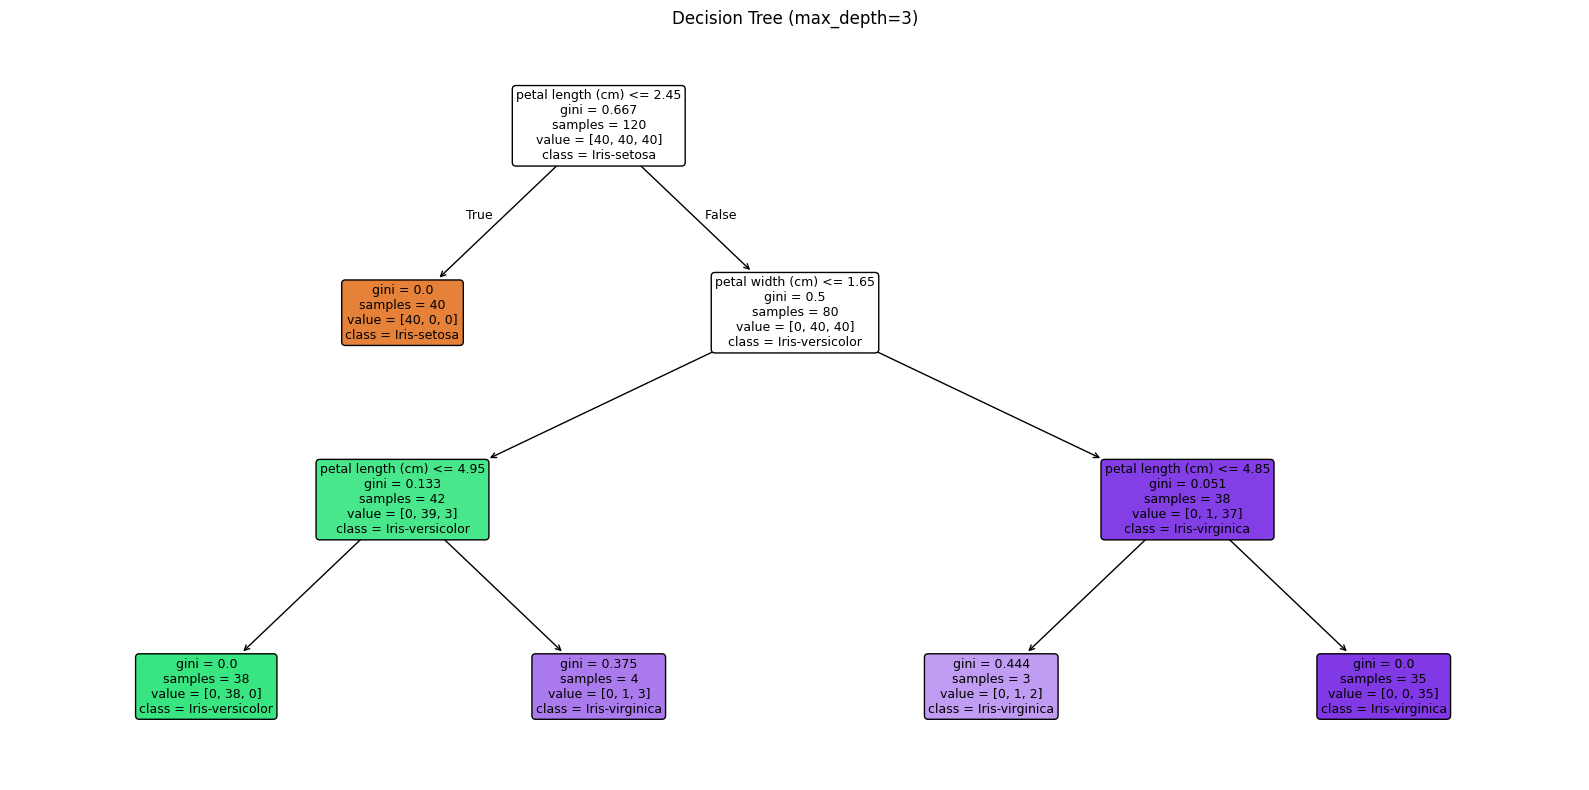

In [6]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth=3)")
plt.tight_layout()
plt.show()

**Reading the tree:** each box shows the splitting condition, the Gini impurity (how mixed
the classes are at that node), how many training samples reached that node, the class counts,
and the majority class. The root node splits first on `petal length (cm)`, which immediately
separates one species out almost perfectly, which is the clearest sign that petal measurements are the
most informative features for this dataset.

## 5. Performance Comparison Across Tree Depths

In [7]:
depths_to_test = [1, 2, 3, 4, 5, 10, None]
results = []

for depth in depths_to_test:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    results.append({
        "max_depth": depth if depth is not None else "None (unlimited)",
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "gap (train - test)": train_acc - test_acc
    })

depth_results = pd.DataFrame(results)
depth_results

,max_depth,train_accuracy,test_accuracy,gap (train - test)
0,1,0.666667,0.666667,0.000000
1,2,0.966667,0.933333,0.033333
2,3,0.983333,0.966667,0.016667
3,4,0.991667,0.933333,0.058333
4,5,1.000000,0.933333,0.066667
5,10,1.000000,0.933333,0.066667
6,None (unlimited),1.000000,0.933333,0.066667


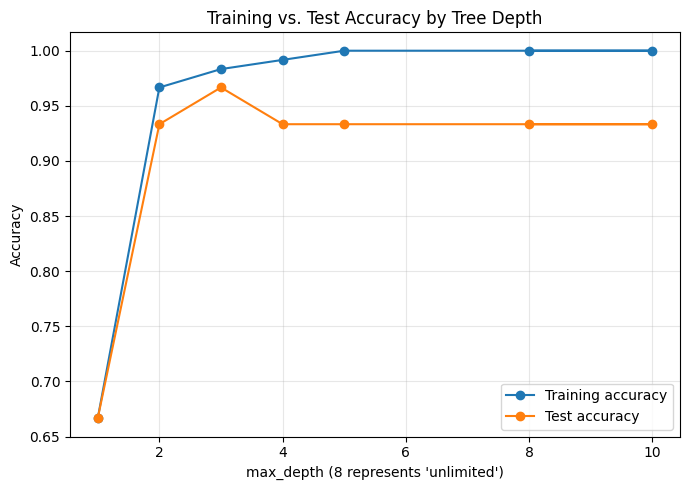

In [8]:
# For plotting, treat "unlimited" depth as a large number so it fits on the same x-axis
plot_depths = [d if d is not None else 8 for d in depths_to_test]

plt.figure(figsize=(7, 5))
plt.plot(plot_depths, depth_results["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(plot_depths, depth_results["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("max_depth (8 represents 'unlimited')")
plt.ylabel("Accuracy")
plt.title("Training vs. Test Accuracy by Tree Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Overfitting Analysis

- **`max_depth=1`** underfits badly: both training (66.7%) and test (66.7%) accuracy are low,
  since a single split can't separate all three species. The model is too simple to capture
  the real pattern in the data.
- **`max_depth=3`** is the sweet spot: training accuracy (98.3%) and test accuracy (96.7%) are
  both high and close together, meaning the model has learned the real pattern without
  memorizing noise.
- **`max_depth=5`** and **unlimited depth** both reach **100% training accuracy**. The tree
  has grown complex enough to perfectly memorize every training example, but test accuracy
  actually *drops* to 93.3%, lower than the simpler `max_depth=3` tree. This is a textbook
  overfitting pattern: the gap between training and test accuracy widens as the tree is
  allowed to grow deeper and more complex, because the extra depth is being used to memorize
  noise and quirks specific to the training set rather than learning anything that generalizes.
- The takeaway: **higher training accuracy does not mean a better model**. What matters is
  test accuracy (performance on unseen data), and in this case, a shallower, simpler tree
  (`max_depth=3`) actually generalizes better than a fully grown one.

## 7. Feature Importance

In [9]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
2,petal length (cm),0.579077
3,petal width (cm),0.420923
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


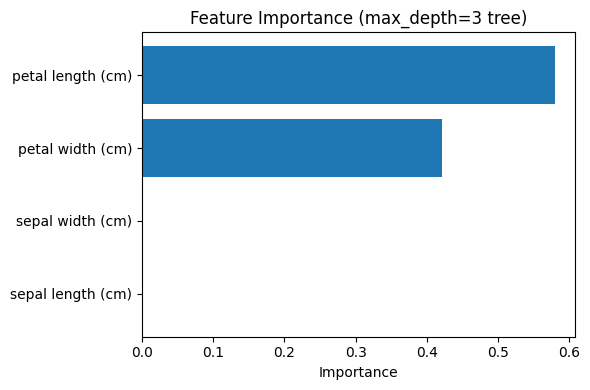

In [10]:
plt.figure(figsize=(6, 4))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (max_depth=3 tree)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation:** `petal length (cm)` and `petal width (cm)` together account for
almost all of the tree's splitting decisions, while `sepal length (cm)` and `sepal width (cm)`
contribute little to nothing. This matches the tree visualization above, where the very first
split was on petal length, and it matches well-known biology for this dataset, since petal
measurements separate the three iris species far more cleanly than sepal measurements do.

## Outcome

This notebook trained a decision tree classifier on the `Iris_Dataset.csv` file, visualized
the resulting tree structure, and compared training vs. test accuracy across seven different
`max_depth` settings (from a single split up to an unlimited depth). The depth comparison
revealed a clear overfitting pattern: very shallow trees underfit (low accuracy on both
training and test data), while very deep trees reached 100% training accuracy but actually
performed *worse* on the test set than a moderately-sized tree. `max_depth=3` struck the best
balance, with 98.3% training accuracy and 96.7% test accuracy. Examining feature importance
confirmed what the tree's own first split already suggested: petal length and petal width
drive nearly all of the model's decisions, while the sepal measurements contribute very
little. This showed concretely why tree depth is a key parameter to tune, not just a setting
to maximize for training performance.